# BrushCue Example: Pixelate

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/pixelate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/pixelate

In [ ]:
!pip install brushcue

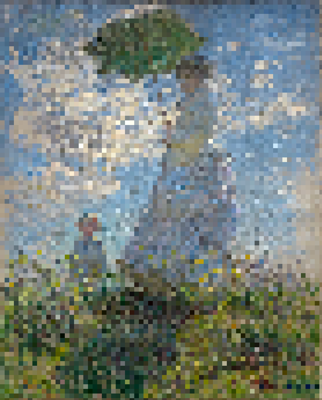

In [1]:
import brushcue
from PIL import Image
import io

image_input_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
string_constant_2 = brushcue.string_constant("let pix_size = u32(pixel_size);\nlet block_corner = (position / pix_size) * pix_size;\nlet center_coord = block_corner + pix_size / 2u;\nlet result = textureLoad(input_texture, center_coord, 0);\nreturn result;")
string_constant_3 = brushcue.string_constant("// No helpers for this tool.")
get_color_profile_4 = brushcue.composition_color_profile(image_input_1)
bool_constant_5 = brushcue.bool_constant(False)
dictionary_create_6 = brushcue.dictionary_create()
string_constant_7 = brushcue.string_constant("pixel_size")
int_add_to_dictionary_8 = brushcue.int_add_to_dictionary(dictionary_create_6, string_constant_7, 25)
pixelate_shader_9 = brushcue.composition_custom_transformer_shader(image_input_1, string_constant_2, string_constant_3, get_color_profile_4, get_color_profile_4, int_add_to_dictionary_8, bool_constant_5)

ctx = brushcue.Context()
result = pixelate_shader_9.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
